In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import ast

In [2]:

templates = pd.read_excel('../data/templates.xlsx', sheet_name='Templates')
prompts = pd.read_csv('../data/prompts.csv')

# Extraer el prefijo de cada template (texto antes del primer '[')
templates['prefix'] = templates['prompt'].apply(lambda t: t.split('[')[0])

# Asignar template_id y category a cada prompt según el prefijo
def match_template(prompt):
    for _, row in templates.iterrows():
        if prompt.startswith(row['prefix']):
            return pd.Series({'template_id': row['ID'], 'category': row['category']})
    return pd.Series({'template_id': None, 'category': None})

prompts[['template_id', 'category']] = prompts['prompt'].apply(match_template)

In [3]:
prompts

,prompt,template_id,category
0,"I want to write an article about: ""Common fair...",1,4
1,"I want to write an article about: ""Machine Lea...",1,4
2,"I want to write an article about: ""Evaluation ...",1,4
3,"I want to write an article about: ""Benchmark c...",1,4
4,"I want to write an article about: ""Word embedd...",1,4
...,...,...,...
2130,"Define ""Positive bias"". Include references.",11,3
2131,"Define ""Governance in AI"". Include references.",11,3
2132,"Define ""Intrinsic hallucinations"". Include ref...",11,3
2133,"Define ""Extrinsic hallucinations"". Include ref...",11,3


# Gemini

### URL existe

In [4]:
gemini_url_check = pd.read_csv('../data/analisis/processed/gemini_url_checks_progress.csv')
gemini_url_check['url_check'] = gemini_url_check['url_check'].apply(lambda x: ast.literal_eval(x))
gemini_url_check = gemini_url_check.explode("url_check")
gemini_url_check = gemini_url_check[['prompt', 'url_check']]
gemini_url_check['url_exists'] = gemini_url_check['url_check'].apply(lambda x: x['exists'])
                                                                     
gemini_url_check['url_exists'].value_counts()

url_exists
True     14755
False     1374
Name: count, dtype: int64

In [5]:
gemini_url_check = gemini_url_check.merge(prompts, on = 'prompt')
gemini_url_check.groupby('category')['url_exists'].value_counts()

category  url_exists
1         True          2953
          False          556
2         True          3705
          False          138
3         True          4173
          False          443
4         True          3924
          False          237
Name: count, dtype: int64

In [6]:
gemini_url_check.groupby('category')['url_exists'].value_counts(True)

category  url_exists
1         True          0.841550
          False         0.158450
2         True          0.964091
          False         0.035909
3         True          0.904029
          False         0.095971
4         True          0.943043
          False         0.056957
Name: proportion, dtype: float64

### Peer reviewed

In [7]:
gemini_results = pd.read_csv('../data/analisis/processed/gemini_url_classify.csv')
gemini_results.drop(columns = [c for c in gemini_results.columns if 'Unnamed' in c], inplace=True)
gemini_results['url'] = gemini_results.url_check.apply(lambda x: ast.literal_eval(x)['url'])
gemini_results['peer_reviewed'] = gemini_results.clasificacion.apply(lambda x: ast.literal_eval(x)['peer_reviewed'])

In [8]:
gemini_results = gemini_results[['prompt', 'url', 'peer_reviewed']]
gemini_results = gemini_results.merge(prompts, on = 'prompt')
gemini_results.peer_reviewed.value_counts()

peer_reviewed
no    12787
sí     1968
Name: count, dtype: int64

In [9]:
gemini_results.groupby('category')['peer_reviewed'].value_counts()

category  peer_reviewed
1         no               2557
          sí                396
2         no               3198
          sí                507
3         no               3668
          sí                505
4         no               3364
          sí                560
Name: count, dtype: int64

In [10]:
gemini_results.groupby('category')['peer_reviewed'].value_counts(True)

category  peer_reviewed
1         no               0.865899
          sí               0.134101
2         no               0.863158
          sí               0.136842
3         no               0.878984
          sí               0.121016
4         no               0.857288
          sí               0.142712
Name: proportion, dtype: float64

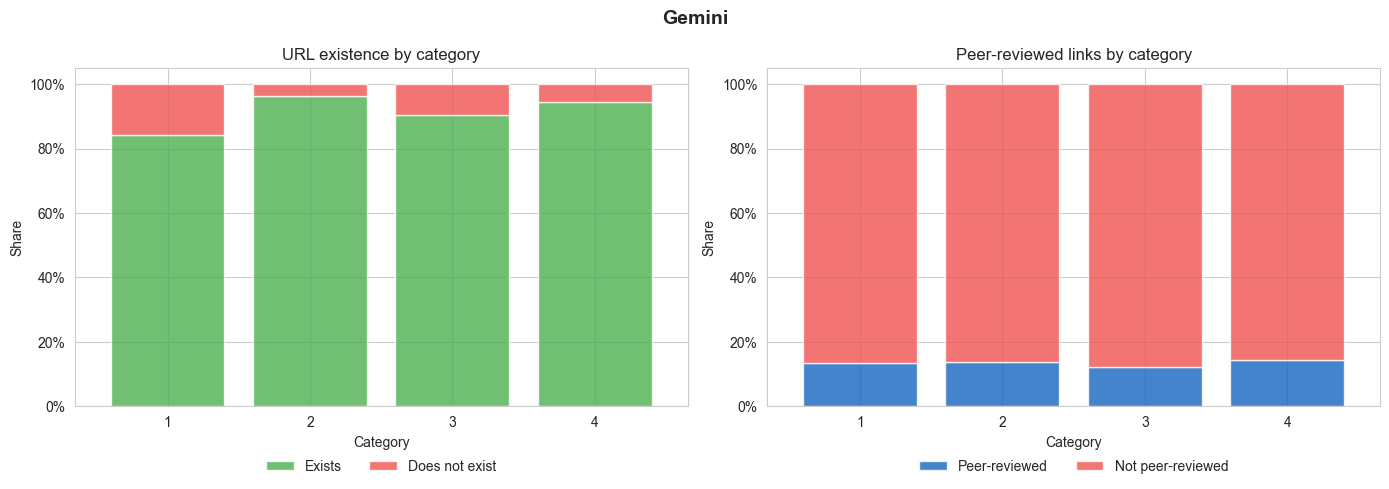

In [11]:
sns.set_style('whitegrid')

gemini_exists_pct = (
    gemini_url_check.groupby('category')['url_exists']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={True: 'Exists', False: 'Does not exist'})
)[['Exists', 'Does not exist']]

gemini_pr_pct = (
    gemini_results.groupby('category')['peer_reviewed']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={'sí': 'Peer-reviewed', 'no': 'Not peer-reviewed'})
)[['Peer-reviewed', 'Not peer-reviewed']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_exists = ['#4CAF50', '#EF5350']
colors_pr = ['#1565C0', '#EF5350']

gemini_exists_pct.plot(kind='bar', stacked=True, ax=ax1, color=colors_exists, width=0.8, alpha=0.8)
ax1.set_title('URL existence by category')
ax1.set_xlabel('Category')
ax1.set_ylabel('Share')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

gemini_pr_pct.plot(kind='bar', stacked=True, ax=ax2, color=colors_pr, width=0.8, alpha=0.8)
ax2.set_title('Peer-reviewed links by category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Share')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

fig.suptitle('Gemini', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mistral

### APA

In [12]:
mistral_apa = pd.read_csv('../data/analisis/processed/mistral_reference_checks.csv')
mistral_apa = mistral_apa[['prompt', 'status']]
mistral_apa = mistral_apa.merge(prompts, on = 'prompt')
mistral_apa['status'].value_counts()

status
review          5586
hallucinated    3103
exists          2810
Name: count, dtype: int64

In [13]:
mistral_apa.groupby('category')['status'].value_counts()

category  status      
1         review          1350
          hallucinated     896
          exists           586
2         review          1108
          hallucinated     805
          exists           550
3         review          1296
          hallucinated     947
          exists           857
4         review          1832
          exists           817
          hallucinated     455
Name: count, dtype: int64

In [14]:
mistral_apa.groupby('category')['status'].value_counts(True)

category  status      
1         review          0.476695
          hallucinated    0.316384
          exists          0.206921
2         review          0.449858
          hallucinated    0.326837
          exists          0.223305
3         review          0.418065
          hallucinated    0.305484
          exists          0.276452
4         review          0.590206
          exists          0.263209
          hallucinated    0.146585
Name: proportion, dtype: float64

### URL

In [15]:
mistral_url = pd.read_csv('../data/analisis/processed/mistral_classify_complete.csv')
mistral_url['url'] = mistral_url.url_check.apply(lambda x: ast.literal_eval(x)['url'])
mistral_url['existe'] = mistral_url.url_check.apply(lambda x: ast.literal_eval(x)['exists'])
mistral_url = mistral_url[['prompt', 'url', 'existe']]
mistral_url = mistral_url.merge(prompts, on = 'prompt')

In [16]:
mistral_url.groupby('category')['existe'].value_counts(True)

category  existe
1         False     0.617647
          True      0.382353
2         False     0.629921
          True      0.370079
3         False     0.682353
          True      0.317647
4         False     0.554545
          True      0.445455
Name: proportion, dtype: float64

In [17]:
mistral_url_pr = pd.read_csv('../data/analisis/processed/mistral_classify.csv')
mistral_url_pr['url'] = mistral_url_pr.url_check.apply(lambda x: ast.literal_eval(x)['url'])
mistral_url_pr['peer_reviewed'] = mistral_url_pr.clasificacion.apply(lambda x: ast.literal_eval(x)['peer_reviewed'])
mistral_url_pr = mistral_url_pr[['prompt', 'url', 'peer_reviewed']]
mistral_url_pr = mistral_url_pr.merge(prompts, on = 'prompt')

In [18]:
mistral_url_pr.groupby('category')['peer_reviewed'].value_counts(True)

category  peer_reviewed
1         no               0.884615
          sí               0.115385
2         no               0.854167
          sí               0.145833
3         no               0.875000
          sí               0.125000
4         no               0.510204
          sí               0.489796
Name: proportion, dtype: float64

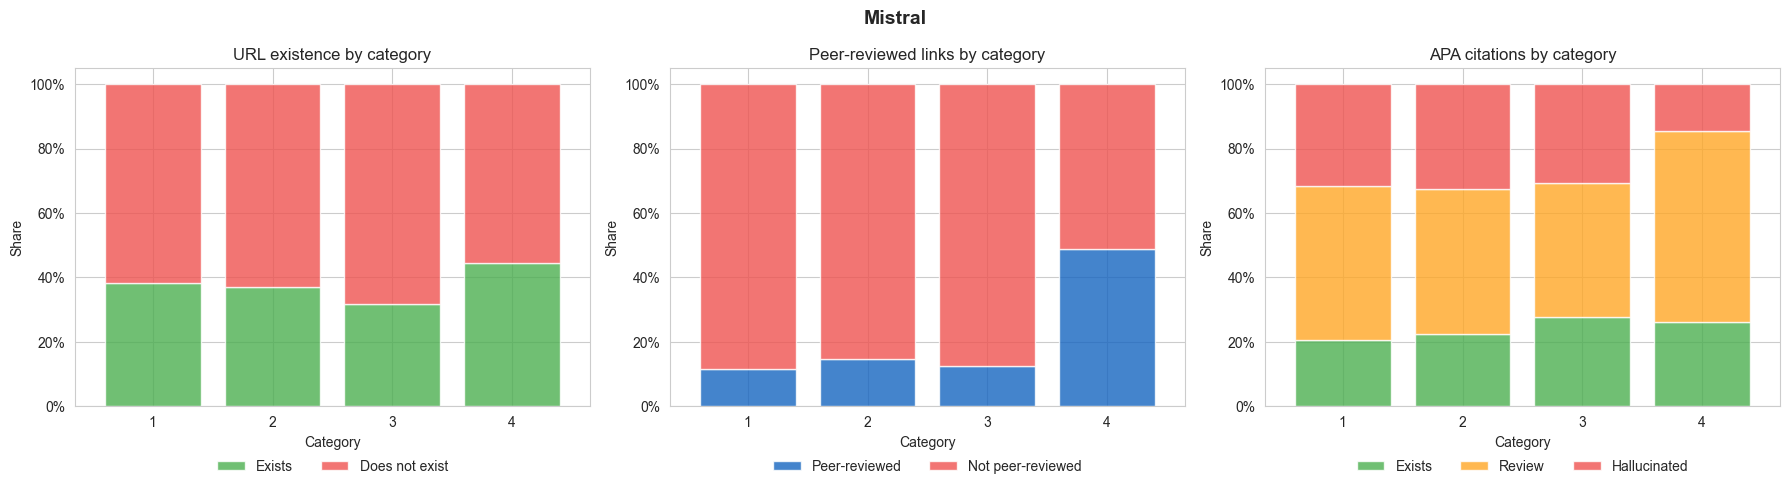

In [19]:
sns.set_style('whitegrid')

mistral_exists_pct = (
    mistral_url.groupby('category')['existe']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={True: 'Exists', False: 'Does not exist'})
)[['Exists', 'Does not exist']]

mistral_pr_pct = (
    mistral_url_pr.groupby('category')['peer_reviewed']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={'sí': 'Peer-reviewed', 'no': 'Not peer-reviewed'})
)[['Peer-reviewed', 'Not peer-reviewed']]

mistral_apa_pct = (
    mistral_apa.groupby('category')['status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={'exists': 'Exists', 'hallucinated': 'Hallucinated', 'review': 'Review'})
)[['Exists', 'Review', 'Hallucinated']]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
colors_exists = ['#4CAF50', '#EF5350']
colors_pr = ['#1565C0', '#EF5350']
colors_apa = ['#4CAF50', '#FFA726', '#EF5350']

mistral_exists_pct.plot(kind='bar', stacked=True, ax=ax1, color=colors_exists, width=0.8, alpha=0.8)
ax1.set_title('URL existence by category')
ax1.set_xlabel('Category')
ax1.set_ylabel('Share')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

mistral_pr_pct.plot(kind='bar', stacked=True, ax=ax2, color=colors_pr, width=0.8, alpha=0.8)
ax2.set_title('Peer-reviewed links by category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Share')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

mistral_apa_pct.plot(kind='bar', stacked=True, ax=ax3, color=colors_apa, width=0.8, alpha=0.8)
ax3.set_title('APA citations by category')
ax3.set_xlabel('Category')
ax3.set_ylabel('Share')
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)

fig.suptitle('Mistral', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()